# Workforce Retention Risk Analytics

This notebook supports the Workforce Retention Risk Analytics portfolio project.

The goal of this project is to analyze an HR employee attrition dataset and build a predictive analytics workflow that supports HR decision-making. Instead of only predicting whether an employee may leave, this notebook also connects the model results to workforce risk indicators, business interpretation, and ethical considerations.

The analysis follows the PACE workflow:

- Plan: define the HR business problem and stakeholder needs
- Analyze: clean the dataset and conduct exploratory data analysis
- Construct: build and evaluate classification models
- Execute: interpret model results and translate findings into HR decision-support recommendations

In [8]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Display settings
pd.set_option("display.max_columns", None)

# Visualization setting
sns.set_theme(style="whitegrid")

print("Packages imported successfully.")

Packages imported successfully.


## 1. Data Loading

This section loads the HR employee attrition dataset from the local project folder.

The target variable is `left`, where:

- `0` means the employee stayed
- `1` means the employee left

In [9]:
file_path = r"C:\Users\USER\Desktop\GADA\Capstone Project\Files\HR_capstone_dataset.csv"

df0 = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df0.shape)

df0.head()

Dataset loaded successfully.
Dataset shape: (14999, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## 2. Initial Data Inspection

This section reviews the basic structure of the dataset, including column names, data types, missing values, and descriptive statistics.

The purpose is to understand the dataset before conducting deeper exploratory data analysis or model construction.

In [10]:
print("Column names:")
print(df0.columns.tolist())

print("\nDataset information:")
df0.info()

Column names:
['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Department', 'salary']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usag

In [11]:
# Descriptive statistics for numeric variables
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


## 3. Column Name Standardization

Some column names are inconsistent or contain spelling issues. This step standardizes column names using snake_case and makes the variable names easier to interpret.

For example:

- `Work_accident` is renamed to `work_accident`
- `average_montly_hours` is corrected to `average_monthly_hours`
- `time_spend_company` is renamed to `tenure`
- `Department` is renamed to `department`

In [12]:
df0 = df0.rename(columns={
    "Work_accident": "work_accident",
    "average_montly_hours": "average_monthly_hours",
    "time_spend_company": "tenure",
    "Department": "department"
})

print("Updated column names:")
print(df0.columns.tolist())

Updated column names:
['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'tenure', 'work_accident', 'left', 'promotion_last_5years', 'department', 'salary']


## 4. Data Quality Check

This section checks missing values and duplicate records.

Missing values may require imputation or removal. Duplicate records may distort model training and business interpretation if they do not represent legitimate repeated observations.

In [14]:
missing_values = df0.isna().sum()

print("Missing values by column:")
print(missing_values)

Missing values by column:
satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64


In [15]:
# Check duplicate rows
duplicate_count = df0.duplicated().sum()
duplicate_percentage = duplicate_count / len(df0) * 100

print("Number of duplicate rows:", duplicate_count)
print(f"Percentage of duplicate rows: {duplicate_percentage:.2f}%")

Number of duplicate rows: 3008
Percentage of duplicate rows: 20.05%


In [16]:
# Inspect duplicated rows
df0[df0.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


The dataset contains a noticeable number of duplicate rows. Because the dataset includes multiple continuous and categorical variables, exact duplicate employee records are unlikely to represent unique real-world employees. Therefore, duplicate rows are removed before further analysis.

In [17]:
# Remove duplicate rows
df1 = df0.drop_duplicates(keep="first").copy()

print("Original dataset shape:", df0.shape)
print("Dataset shape after removing duplicates:", df1.shape)

df1.head()

Original dataset shape: (14999, 10)
Dataset shape after removing duplicates: (11991, 10)


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## 5. Attrition Summary

This section summarizes how many employees stayed and how many employees left.

The target variable is `left`:

- `0` = employee stayed
- `1` = employee left

This step helps establish the baseline attrition rate before building predictive models.

In [18]:
attrition_counts = df1["left"].value_counts().sort_index()
attrition_percentages = df1["left"].value_counts(normalize=True).sort_index() * 100

attrition_summary = pd.DataFrame({
    "employee_status": ["Stayed", "Left"],
    "count": attrition_counts.values,
    "percentage": attrition_percentages.values
})

attrition_summary

,employee_status,count,percentage
0,Stayed,10000,83.39588
1,Left,1991,16.60412


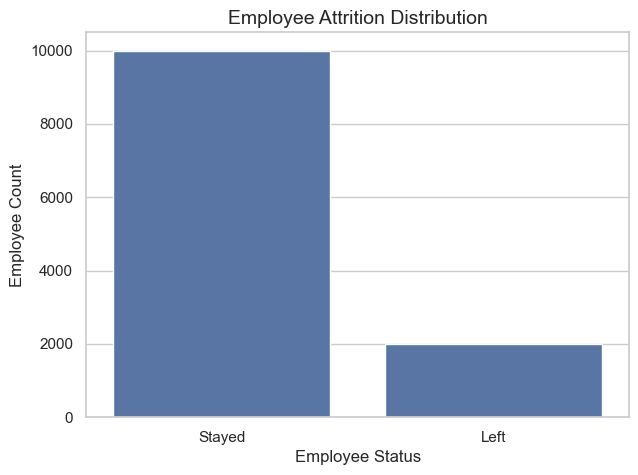

In [19]:
# Visualize employee attrition distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df1, x="left")

plt.title("Employee Attrition Distribution", fontsize=14)
plt.xlabel("Employee Status")
plt.ylabel("Employee Count")
plt.xticks(ticks=[0, 1], labels=["Stayed", "Left"])

plt.show()

## 6. Outlier Check

This section checks potential outliers in the `tenure` variable using the interquartile range method.

Outlier detection is important because some models, especially logistic regression, can be sensitive to extreme values.

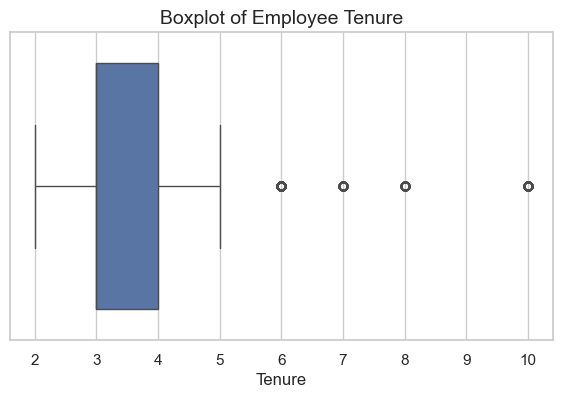

In [23]:
plt.figure(figsize=(7, 4))

sns.boxplot(x=df1["tenure"])

plt.title("Boxplot of Employee Tenure", fontsize=14)
plt.xlabel("Tenure")

plt.show()

In [24]:
# Calculate IQR boundaries for tenure

percentile25 = df1["tenure"].quantile(0.25)
percentile75 = df1["tenure"].quantile(0.75)
iqr = percentile75 - percentile25

lower_limit = percentile25 - 1.5 * iqr
upper_limit = percentile75 + 1.5 * iqr

tenure_outliers = df1[
    (df1["tenure"] < lower_limit) |
    (df1["tenure"] > upper_limit)
]

print("25th percentile:", percentile25)
print("75th percentile:", percentile75)
print("IQR:", iqr)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
print("Number of tenure outliers:", len(tenure_outliers))
print(f"Percentage of tenure outliers: {len(tenure_outliers) / len(df1) * 100:.2f}%")

25th percentile: 3.0
75th percentile: 4.0
IQR: 1.0
Lower limit: 1.5
Upper limit: 5.5
Number of tenure outliers: 824
Percentage of tenure outliers: 6.87%


The tenure variable contains some outliers based on the IQR rule. These observations may represent longer-tenured employees.

For tree-based models, these outliers may be retained because decision trees and random forests are generally less sensitive to outliers. For logistic regression, removing or reviewing outliers may be appropriate because logistic regression is more sensitive to extreme values.

## 7. Monthly Working Hours and Attrition

This section examines whether employees who left the company worked different monthly hours compared with those who stayed.

This is important because excessive working hours may indicate overwork, burnout risk, or workload imbalance.

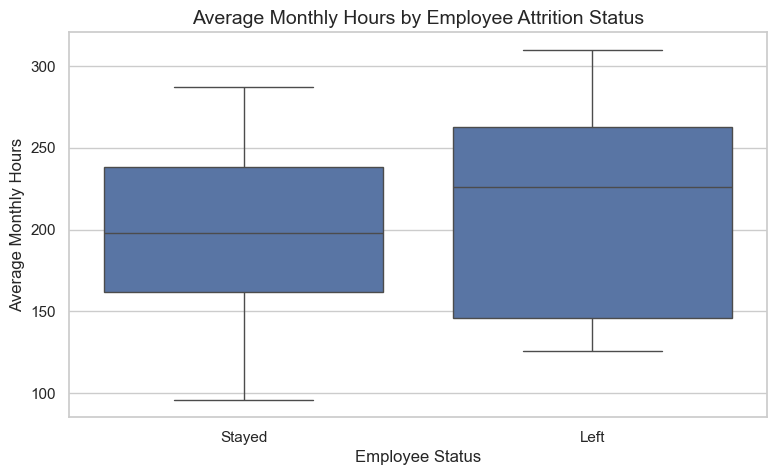

In [27]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df1,
    x="left",
    y="average_monthly_hours"
)

plt.title("Average Monthly Hours by Employee Attrition Status", fontsize=14)
plt.xlabel("Employee Status")
plt.ylabel("Average Monthly Hours")
plt.xticks(ticks=[0, 1], labels=["Stayed", "Left"])

plt.show()

In [28]:
# Summary statistics of monthly hours by attrition status

monthly_hours_summary = df1.groupby("left")["average_monthly_hours"].agg(
    count="count",
    mean="mean",
    median="median",
    min="min",
    max="max"
)

monthly_hours_summary.index = ["Stayed", "Left"]

monthly_hours_summary

,count,mean,median,min,max
Stayed,10000,198.94270,198.0,96,287
Left,1991,208.16223,226.0,126,310


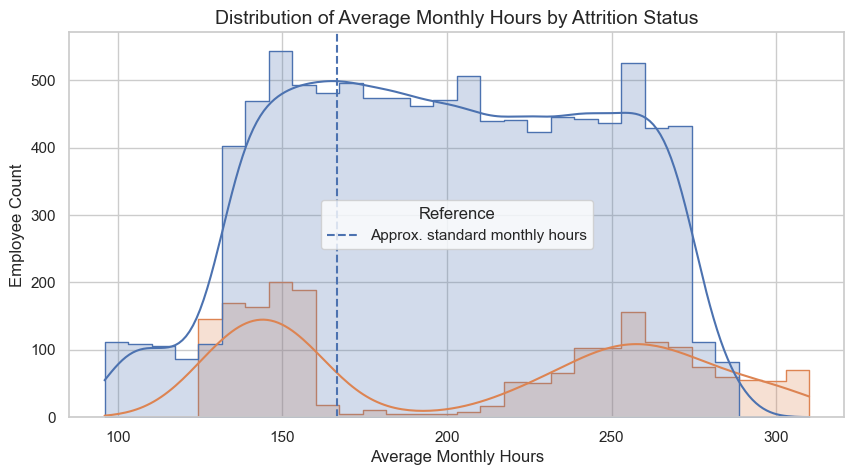

In [29]:
# Histogram of average monthly hours by attrition status

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df1,
    x="average_monthly_hours",
    hue="left",
    bins=30,
    kde=True,
    element="step"
)

plt.axvline(x=166.67, linestyle="--", label="Approx. standard monthly hours")
plt.title("Distribution of Average Monthly Hours by Attrition Status", fontsize=14)
plt.xlabel("Average Monthly Hours")
plt.ylabel("Employee Count")
plt.legend(title="Reference")

plt.show()

The monthly working hour distribution helps identify whether attrition is associated with unusually high workload. The reference line around 166.67 hours represents an approximate standard monthly workload based on a 40-hour work week.

## 8. Number of Projects and Attrition

This section examines whether the number of assigned projects is associated with employee attrition.

A high number of projects may indicate workload pressure, role overload, or insufficient staffing.

project_attrition_table = pd.crosstab(
    df1["number_project"],
    df1["left"],
    margins=True
)

project_attrition_table

In [30]:
# Attrition rate by number of projects

project_attrition_rate = (
    df1.groupby("number_project")["left"]
    .mean()
    .reset_index()
    .rename(columns={"left": "attrition_rate"})
)

project_attrition_rate["attrition_rate_percent"] = project_attrition_rate["attrition_rate"] * 100

project_attrition_rate

,number_project,attrition_rate,attrition_rate_percent
0,2,0.541719,54.171934
1,3,0.010795,1.079545
2,4,0.064315,6.431479
3,5,0.153605,15.360502
4,6,0.449153,44.915254
5,7,1.000000,100.000000


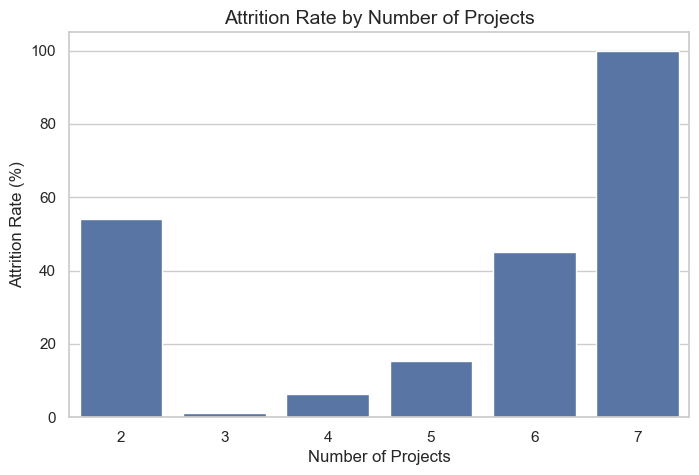

In [31]:
# Visualize attrition rate by number of projects

plt.figure(figsize=(8, 5))

sns.barplot(
    data=project_attrition_rate,
    x="number_project",
    y="attrition_rate_percent"
)

plt.title("Attrition Rate by Number of Projects", fontsize=14)
plt.xlabel("Number of Projects")
plt.ylabel("Attrition Rate (%)")

plt.show()

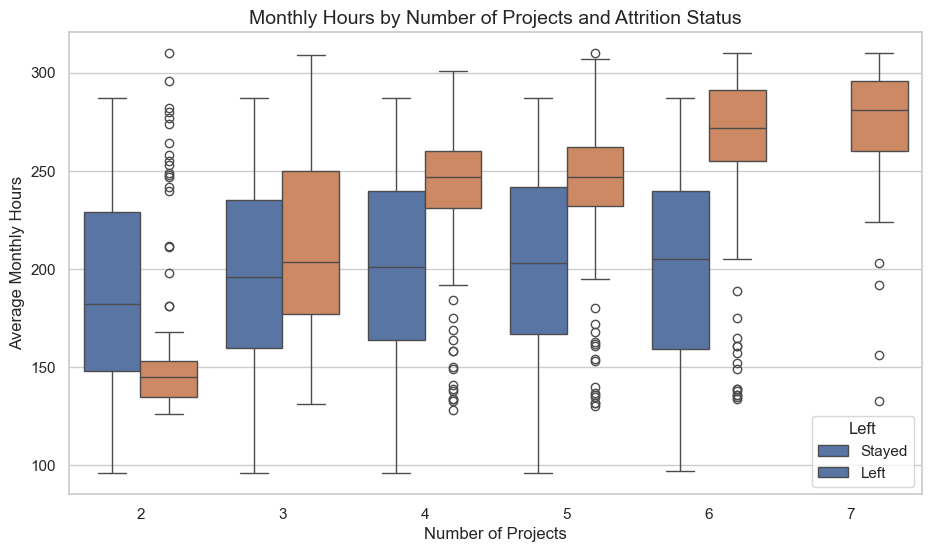

In [32]:
# Boxplot: monthly hours by number of projects and attrition status

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df1,
    x="number_project",
    y="average_monthly_hours",
    hue="left"
)

plt.title("Monthly Hours by Number of Projects and Attrition Status", fontsize=14)
plt.xlabel("Number of Projects")
plt.ylabel("Average Monthly Hours")
plt.legend(title="Left", labels=["Stayed", "Left"])

plt.show()

The relationship between project count and attrition is especially important for HR decision-making. If attrition increases sharply among employees assigned to many projects, project allocation may be a key area for retention intervention.

## 9. Satisfaction Level and Attrition

This section examines how employee satisfaction differs between employees who stayed and employees who left.

Satisfaction level is expected to be strongly related to attrition. However, in a real-world deployment setting, satisfaction data may not always be available, updated, or appropriate for prediction.

In [33]:
satisfaction_summary = df1.groupby("left")["satisfaction_level"].agg(
    count="count",
    mean="mean",
    median="median",
    min="min",
    max="max"
)

satisfaction_summary.index = ["Stayed", "Left"]

satisfaction_summary

,count,mean,median,min,max
Stayed,10000,0.667365,0.69,0.12,1.00
Left,1991,0.440271,0.41,0.09,0.92


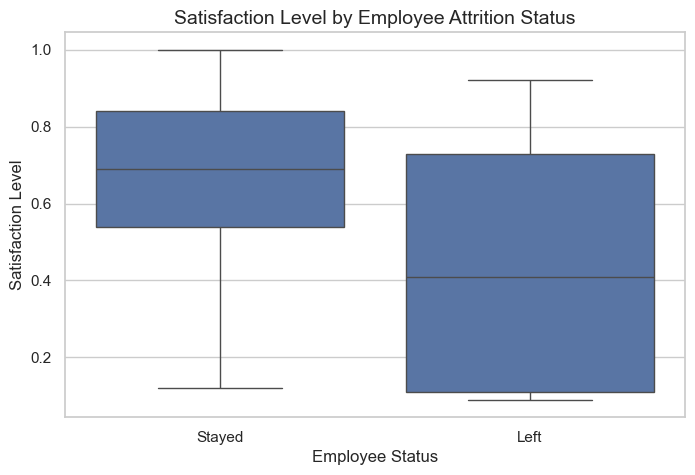

In [34]:
# Boxplot of satisfaction level by attrition status

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df1,
    x="left",
    y="satisfaction_level"
)

plt.title("Satisfaction Level by Employee Attrition Status", fontsize=14)
plt.xlabel("Employee Status")
plt.ylabel("Satisfaction Level")
plt.xticks(ticks=[0, 1], labels=["Stayed", "Left"])

plt.show()

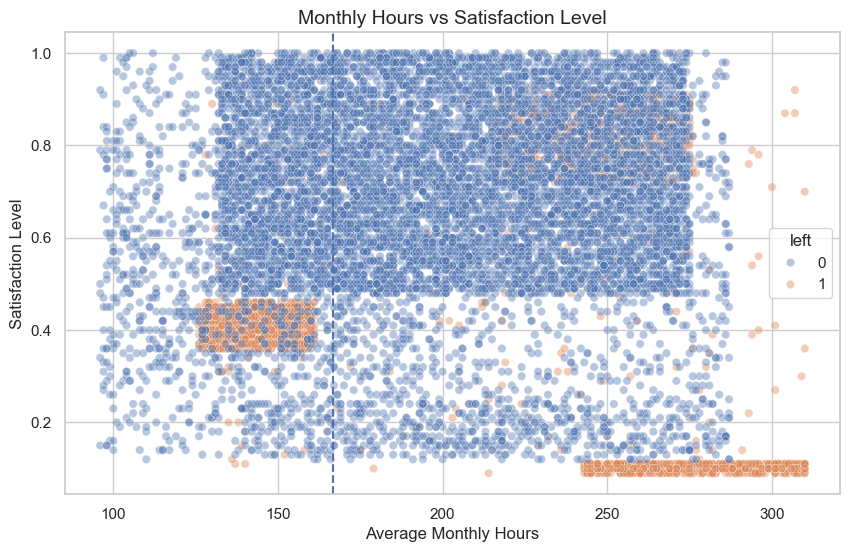

In [35]:
# Scatterplot: monthly hours vs satisfaction level

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df1,
    x="average_monthly_hours",
    y="satisfaction_level",
    hue="left",
    alpha=0.4
)

plt.axvline(x=166.67, linestyle="--", label="Approx. standard monthly hours")
plt.title("Monthly Hours vs Satisfaction Level", fontsize=14)
plt.xlabel("Average Monthly Hours")
plt.ylabel("Satisfaction Level")

plt.show()

This visualization helps identify whether low satisfaction and high workload appear together among employees who left. This relationship is important for interpreting attrition as a potential workforce management issue rather than only an individual employee decision.

In [37]:
tenure_attrition_summary = df1.groupby("tenure")["left"].agg(
    employee_count="count",
    attrition_rate="mean"
).reset_index()

tenure_attrition_summary["attrition_rate_percent"] = (
    tenure_attrition_summary["attrition_rate"] * 100
)

tenure_attrition_summary

,tenure,employee_count,attrition_rate,attrition_rate_percent
0,2,2910,0.010653,1.065292
1,3,5190,0.168401,16.840077
2,4,2005,0.246883,24.688279
3,5,1062,0.453861,45.386064
4,6,542,0.201107,20.110701
5,7,94,0.000000,0.000000
6,8,81,0.000000,0.000000
7,10,107,0.000000,0.000000


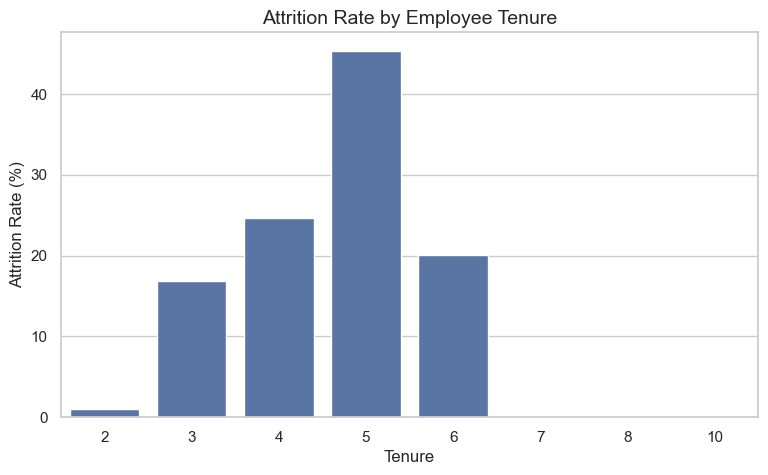

In [38]:
# Visualize attrition rate by tenure

plt.figure(figsize=(9, 5))

sns.barplot(
    data=tenure_attrition_summary,
    x="tenure",
    y="attrition_rate_percent"
)

plt.title("Attrition Rate by Employee Tenure", fontsize=14)
plt.xlabel("Tenure")
plt.ylabel("Attrition Rate (%)")

plt.show()

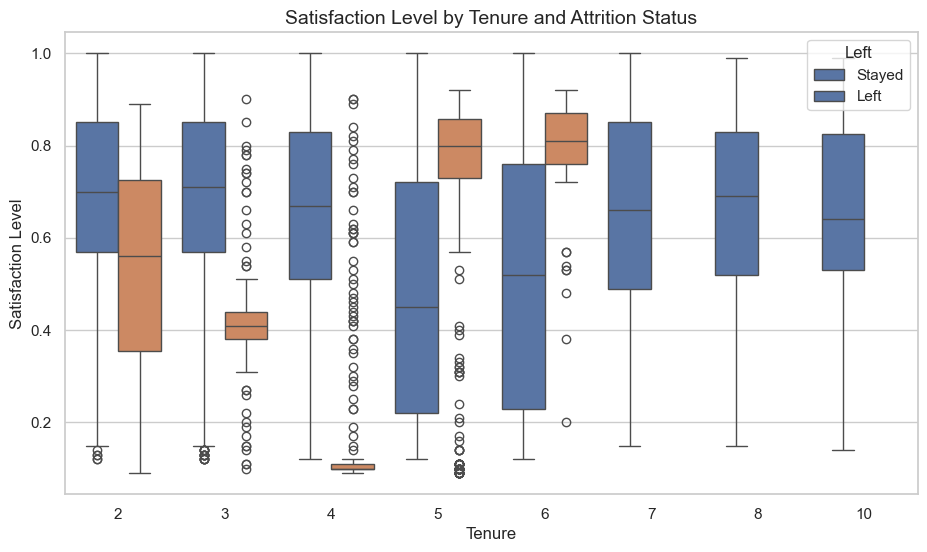

In [39]:
# Satisfaction level by tenure and attrition status

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df1,
    x="tenure",
    y="satisfaction_level",
    hue="left"
)

plt.title("Satisfaction Level by Tenure and Attrition Status", fontsize=14)
plt.xlabel("Tenure")
plt.ylabel("Satisfaction Level")
plt.legend(title="Left", labels=["Stayed", "Left"])

plt.show()

Tenure-based attrition patterns can help HR identify whether turnover risk is concentrated among newer employees, mid-tenure employees, or long-tenured employees. If specific tenure groups show higher attrition risk, HR may need to review onboarding, promotion timing, workload progression, or career development support.

## 11. Promotion, Salary, and Attrition

This section explores whether promotion history and salary category are associated with employee attrition.

Promotion and compensation are important workforce management variables because they may influence employee motivation, perceived fairness, and long-term retention.

In [40]:
# =========================
# Chunk 12: Promotion and attrition
# =========================

promotion_attrition_summary = df1.groupby("promotion_last_5years")["left"].agg(
    employee_count="count",
    attrition_rate="mean"
).reset_index()

promotion_attrition_summary["attrition_rate_percent"] = (
    promotion_attrition_summary["attrition_rate"] * 100
)

promotion_attrition_summary

,promotion_last_5years,employee_count,attrition_rate,attrition_rate_percent
0,0,11788,0.168222,16.822192
1,1,203,0.039409,3.940887


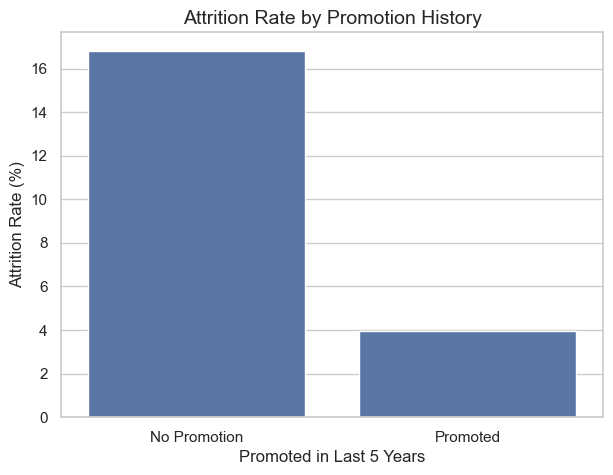

In [41]:
# Visualize attrition rate by promotion history

plt.figure(figsize=(7, 5))

sns.barplot(
    data=promotion_attrition_summary,
    x="promotion_last_5years",
    y="attrition_rate_percent"
)

plt.title("Attrition Rate by Promotion History", fontsize=14)
plt.xlabel("Promoted in Last 5 Years")
plt.ylabel("Attrition Rate (%)")
plt.xticks(ticks=[0, 1], labels=["No Promotion", "Promoted"])

plt.show()

In [42]:
# Salary and attrition summary

salary_attrition_summary = df1.groupby("salary")["left"].agg(
    employee_count="count",
    attrition_rate="mean"
).reset_index()

salary_attrition_summary["attrition_rate_percent"] = (
    salary_attrition_summary["attrition_rate"] * 100
)

salary_attrition_summary

,salary,employee_count,attrition_rate,attrition_rate_percent
0,high,990,0.048485,4.848485
1,low,5740,0.204530,20.452962
2,medium,5261,0.146170,14.616993


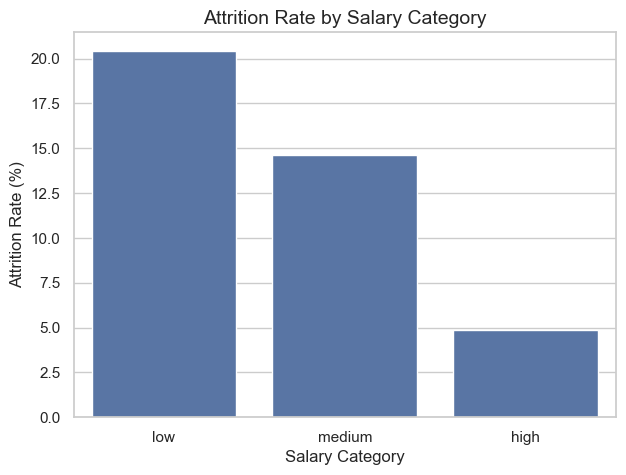

In [43]:
# Visualize attrition rate by salary category

salary_order = ["low", "medium", "high"]

plt.figure(figsize=(7, 5))

sns.barplot(
    data=salary_attrition_summary,
    x="salary",
    y="attrition_rate_percent",
    order=salary_order
)

plt.title("Attrition Rate by Salary Category", fontsize=14)
plt.xlabel("Salary Category")
plt.ylabel("Attrition Rate (%)")

plt.show()

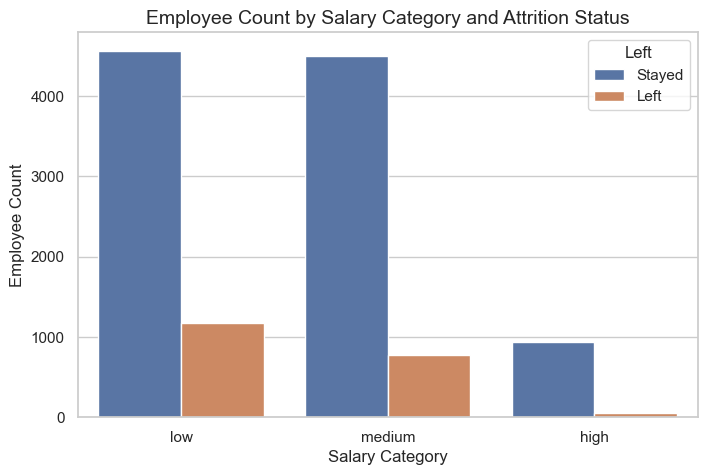

In [44]:
# Salary distribution by attrition status

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df1,
    x="salary",
    hue="left",
    order=salary_order
)

plt.title("Employee Count by Salary Category and Attrition Status", fontsize=14)
plt.xlabel("Salary Category")
plt.ylabel("Employee Count")
plt.legend(title="Left", labels=["Stayed", "Left"])

plt.show()

Promotion and salary patterns should be interpreted carefully. A lower attrition rate among promoted employees may suggest that career advancement is related to retention, but this does not prove causality. Salary categories may also reflect job level, department, or role type, so additional context would be needed before making compensation-related decisions.

## 12. Department-Level Attrition Analysis

This section examines whether employee attrition differs across departments.

Department-level analysis can help identify whether turnover risk is concentrated in specific organizational units or whether the issue appears more company-wide.

In [46]:
department_attrition_summary = df1.groupby("department")["left"].agg(
    employee_count="count",
    attrition_rate="mean"
).reset_index()

department_attrition_summary["attrition_rate_percent"] = (
    department_attrition_summary["attrition_rate"] * 100
)

department_attrition_summary = department_attrition_summary.sort_values(
    by="attrition_rate_percent",
    ascending=False
)

department_attrition_summary

,department,employee_count,attrition_rate,attrition_rate_percent
3,hr,601,0.188020,18.801997
2,accounting,621,0.175523,17.552335
9,technical,2244,0.173797,17.379679
8,support,1821,0.171334,17.133443
7,sales,3239,0.169805,16.980550
5,marketing,673,0.166419,16.641902
0,IT,976,0.161885,16.188525
6,product_mng,686,0.160350,16.034985
1,RandD,694,0.122478,12.247839
4,management,436,0.119266,11.926606


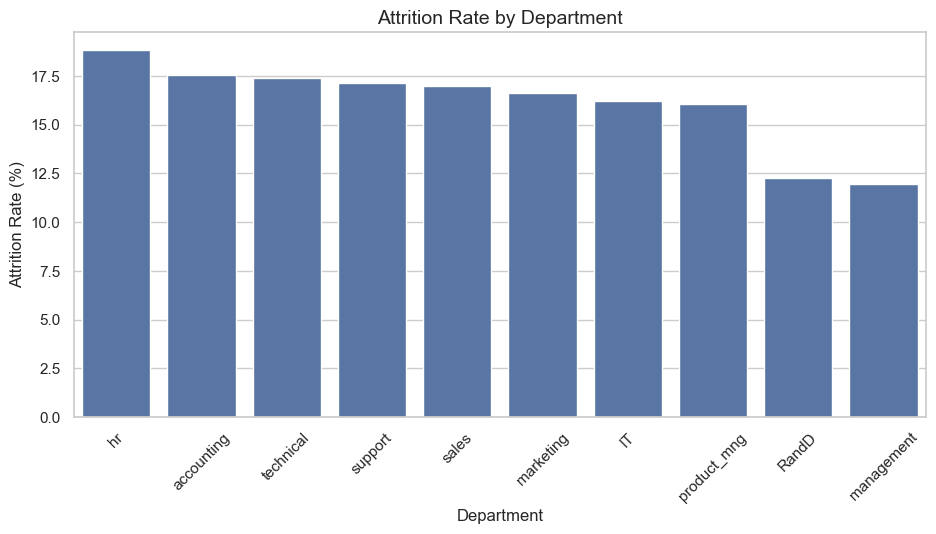

In [47]:
# Visualize attrition rate by department

plt.figure(figsize=(11, 5))

sns.barplot(
    data=department_attrition_summary,
    x="department",
    y="attrition_rate_percent"
)

plt.title("Attrition Rate by Department", fontsize=14)
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45)

plt.show()

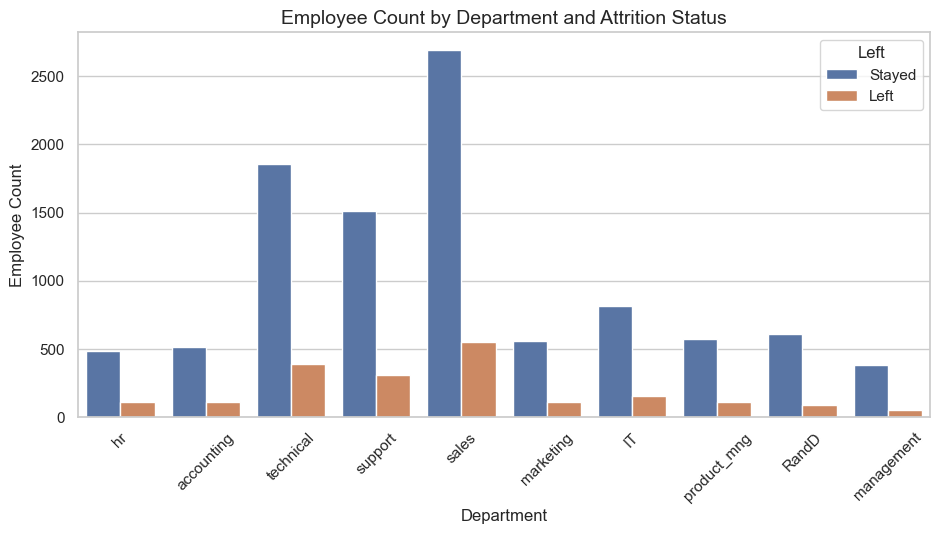

In [48]:
# Department employee count by attrition status

plt.figure(figsize=(11, 5))

sns.countplot(
    data=df1,
    x="department",
    hue="left",
    order=department_attrition_summary["department"]
)

plt.title("Employee Count by Department and Attrition Status", fontsize=14)
plt.xlabel("Department")
plt.ylabel("Employee Count")
plt.xticks(rotation=45)
plt.legend(title="Left", labels=["Stayed", "Left"])

plt.show()

Department-level results can help HR decide whether retention strategies should be company-wide or targeted toward specific units. However, department-level differences should not be overinterpreted without considering department size, job type, workload, compensation, and management structure.

## 13. Correlation Analysis

This section examines correlations among numerical variables.

Correlation analysis helps identify relationships between variables before modeling. It can also reveal whether some predictors are strongly related to each other, which may affect model interpretation.

In [49]:
numeric_columns = [
    "satisfaction_level",
    "last_evaluation",
    "number_project",
    "average_monthly_hours",
    "tenure",
    "work_accident",
    "left",
    "promotion_last_5years"
]

correlation_matrix = df1[numeric_columns].corr()

correlation_matrix

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years
satisfaction_level,1.000000,0.095186,-0.133246,-0.006252,-0.152915,0.039940,-0.350558,0.019789
last_evaluation,0.095186,1.000000,0.270256,0.264678,0.096829,-0.005695,0.013520,-0.007206
number_project,-0.133246,0.270256,1.000000,0.331516,0.188837,-0.005612,0.030928,-0.000544
average_monthly_hours,-0.006252,0.264678,0.331516,1.000000,0.102875,-0.012860,0.070409,-0.004964
tenure,-0.152915,0.096829,0.188837,0.102875,1.000000,0.000003,0.173295,0.056828
work_accident,0.039940,-0.005695,-0.005612,-0.012860,0.000003,1.000000,-0.125436,0.029852
left,-0.350558,0.013520,0.030928,0.070409,0.173295,-0.125436,1.000000,-0.044657
promotion_last_5years,0.019789,-0.007206,-0.000544,-0.004964,0.056828,0.029852,-0.044657,1.000000


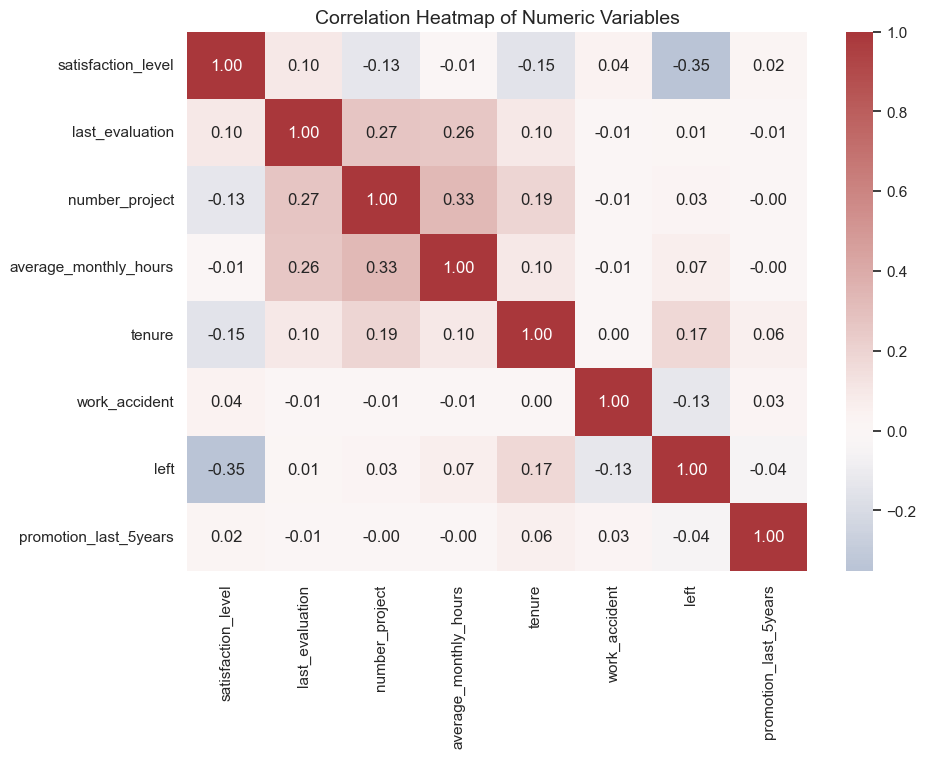

In [50]:
# Visualize correlation heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0
)

plt.title("Correlation Heatmap of Numeric Variables", fontsize=14)

plt.show()

The correlation heatmap provides an initial view of how numerical variables relate to one another. In this project, special attention should be given to relationships involving attrition, satisfaction level, number of projects, monthly hours, tenure, and evaluation score.

## 14. Business Interpretation from Exploratory Data Analysis

The exploratory analysis suggests that employee attrition may be related to workload pressure, project burden, satisfaction level, tenure, and promotion history.

Several business-facing observations can be drawn from the EDA:

1. **Workload pressure may be an important attrition signal.**  
   Employees with higher monthly working hours may face higher burnout risk or dissatisfaction.

2. **Project overload may contribute to turnover risk.**  
   Employees assigned to many projects may experience role overload, competing deadlines, or insufficient support.

3. **Satisfaction level appears strongly related to attrition.**  
   Employees who left tend to show lower satisfaction levels. However, satisfaction data may not always be available in real-world deployment, so it should be used carefully.

4. **Promotion history may be relevant to retention.**  
   Employees who have not been promoted may be more likely to leave, although further analysis would be needed to understand whether this reflects career stagnation, role differences, or other organizational factors.

5. **Tenure patterns may reveal timing-related risk.**  
   If attrition is concentrated around specific tenure levels, HR may need to review onboarding, career pathing, workload progression, or promotion timing.

From a decision-support perspective, the purpose of this analysis is not only to predict who may leave, but also to help HR identify which workforce conditions may require intervention.

In [51]:
# =========================
# Portfolio KPI summary
# =========================

overall_attrition_rate = df1["left"].mean() * 100
average_monthly_hours = df1["average_monthly_hours"].mean()
overwork_rate = (df1["average_monthly_hours"] > 175).mean() * 100
project_overload_rate = (df1["number_project"] >= 6).mean() * 100
promotion_gap_rate = (df1["promotion_last_5years"] == 0).mean() * 100

kpi_summary = pd.DataFrame({
    "KPI": [
        "Attrition Rate",
        "Average Monthly Hours",
        "Overwork Rate (>175 hours/month)",
        "Project Overload Rate (>=6 projects)",
        "Promotion Gap Rate"
    ],
    "Value": [
        f"{overall_attrition_rate:.2f}%",
        f"{average_monthly_hours:.2f}",
        f"{overwork_rate:.2f}%",
        f"{project_overload_rate:.2f}%",
        f"{promotion_gap_rate:.2f}%"
    ],
    "Business Meaning": [
        "Overall percentage of employees who left",
        "Average workload level across employees",
        "Share of employees working above the defined overwork threshold",
        "Share of employees assigned to a high number of projects",
        "Share of employees without promotion in the last five years"
    ]
})

kpi_summary

,KPI,Value,Business Meaning
0,Attrition Rate,16.60%,Overall percentage of employees who left
1,Average Monthly Hours,200.47,Average workload level across employees
2,Overwork Rate (>175 hours/month),63.63%,Share of employees working above the defined o...
3,Project Overload Rate (>=6 projects),8.10%,Share of employees assigned to a high number o...
4,Promotion Gap Rate,98.31%,Share of employees without promotion in the la...


The KPI summary table translates exploratory findings into business-facing indicators. These indicators can later support a Tableau dashboard and help HR stakeholders monitor attrition risk at the workforce level.

## 15. Feature Preparation and Categorical Encoding

Before building classification models, categorical variables need to be converted into numeric format.

In this dataset:

- `salary` is an ordinal categorical variable with an order: low, medium, high.
- `department` is a nominal categorical variable, so it is converted into dummy variables.

The target variable is `left`.

In [53]:
df_model = df1.copy()

# Encode salary as an ordinal variable
df_model["salary"] = (
    df_model["salary"]
    .astype("category")
    .cat.set_categories(["low", "medium", "high"])
    .cat.codes
)

# Dummy encode department
df_model = pd.get_dummies(
    df_model,
    columns=["department"],
    drop_first=False
)

print("Encoded dataset shape:", df_model.shape)
df_model.head()

Encoded dataset shape: (11991, 19)


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


In [54]:
# Check encoded columns

df_model.columns.tolist()

['satisfaction_level',
 'last_evaluation',
 'number_project',
 'average_monthly_hours',
 'tenure',
 'work_accident',
 'left',
 'promotion_last_5years',
 'salary',
 'department_IT',
 'department_RandD',
 'department_accounting',
 'department_hr',
 'department_management',
 'department_marketing',
 'department_product_mng',
 'department_sales',
 'department_support',
 'department_technical']

## 16. Train-Test Split

The dataset is split into training and testing sets.

The training set is used to train the models, while the testing set is reserved for evaluating model performance on unseen data.

Because employee attrition is a binary classification problem and the classes are not perfectly balanced, stratified sampling is used to preserve the proportion of employees who stayed and left in both training and testing sets.

In [55]:
X = df_model.drop("left", axis=1)
y = df_model["left"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (8993, 18)
X_test shape: (2998, 18)
y_train distribution:
left
0    0.833982
1    0.166018
Name: proportion, dtype: float64

y_test distribution:
left
0    0.833889
1    0.166111
Name: proportion, dtype: float64


## 17. Baseline Model: Logistic Regression

Logistic regression is used as a baseline classification model.

This model is relatively interpretable and provides a useful starting point for evaluating whether employee attrition can be predicted from the available features.

However, logistic regression may be sensitive to outliers and may not capture complex nonlinear relationships as effectively as tree-based models.

In [56]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [57]:
# Logistic regression classification report

print("Logistic Regression Classification Report:")
print(classification_report(y_test, log_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      2500
           1       0.51      0.18      0.27       498

    accuracy                           0.83      2998
   macro avg       0.68      0.57      0.59      2998
weighted avg       0.80      0.83      0.80      2998



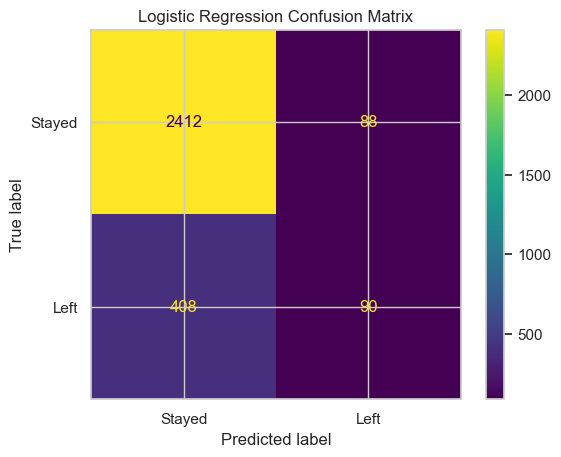

In [58]:
# Logistic regression confusion matrix

log_cm = confusion_matrix(y_test, log_pred)

log_disp = ConfusionMatrixDisplay(
    confusion_matrix=log_cm,
    display_labels=["Stayed", "Left"]
)

log_disp.plot(values_format="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [59]:
# Logistic regression performance summary

log_results = pd.DataFrame({
    "model": ["Logistic Regression"],
    "accuracy": [accuracy_score(y_test, log_pred)],
    "precision": [precision_score(y_test, log_pred)],
    "recall": [recall_score(y_test, log_pred)],
    "f1_score": [f1_score(y_test, log_pred)],
    "roc_auc": [roc_auc_score(y_test, log_pred)]
})

log_results

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.834556,0.505618,0.180723,0.266272,0.572761


The logistic regression model provides a baseline for comparison. If the model has low recall for employees who left, it may miss employees who are actually at risk of attrition. For HR decision support, recall can be especially important because missing high-risk employees may reduce the usefulness of early intervention.

## 18. Decision Tree Model

A decision tree model is used to capture nonlinear relationships and interaction effects between variables.

Decision trees are easier to interpret than many other machine learning models because they split data based on feature thresholds. This makes them useful for business-facing explanation.

However, decision trees may overfit if not controlled through hyperparameter tuning.

In [60]:
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=6,
    min_samples_leaf=5
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [61]:
# Decision tree classification report

print("Decision Tree Classification Report:")
print(classification_report(y_test, tree_pred))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2500
           1       0.97      0.92      0.95       498

    accuracy                           0.98      2998
   macro avg       0.98      0.96      0.97      2998
weighted avg       0.98      0.98      0.98      2998



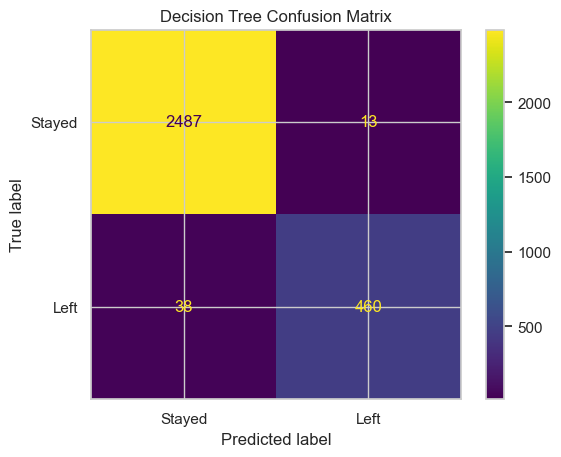

In [62]:
# Decision tree confusion matrix

tree_cm = confusion_matrix(y_test, tree_pred)

tree_disp = ConfusionMatrixDisplay(
    confusion_matrix=tree_cm,
    display_labels=["Stayed", "Left"]
)

tree_disp.plot(values_format="d")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [63]:
# Decision tree performance summary

tree_results = pd.DataFrame({
    "model": ["Decision Tree"],
    "accuracy": [accuracy_score(y_test, tree_pred)],
    "precision": [precision_score(y_test, tree_pred)],
    "recall": [recall_score(y_test, tree_pred)],
    "f1_score": [f1_score(y_test, tree_pred)],
    "roc_auc": [roc_auc_score(y_test, tree_pred)]
})

tree_results

,model,accuracy,precision,recall,f1_score,roc_auc
0,Decision Tree,0.982989,0.972516,0.923695,0.947477,0.959247


In [64]:
# Decision tree feature importance

tree_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": tree_model.feature_importances_
})

tree_importance = tree_importance.sort_values(
    by="importance",
    ascending=False
)

tree_importance.head(10)

,feature,importance
0,satisfaction_level,0.501077
1,last_evaluation,0.169722
2,number_project,0.132868
4,tenure,0.121314
3,average_monthly_hours,0.074426
8,department_IT,0.000240
7,salary,0.000154
16,department_support,0.000134
17,department_technical,0.000065
6,promotion_last_5years,0.000000


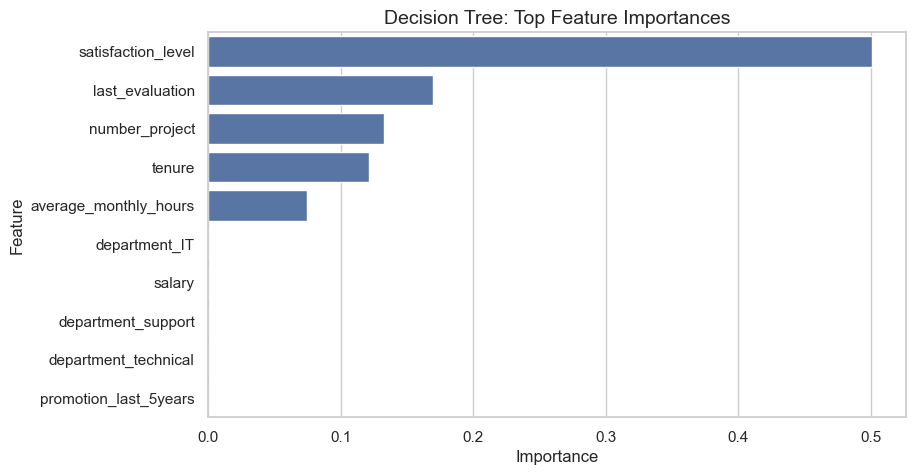

In [65]:
# Visualize top decision tree feature importances

top_tree_importance = tree_importance.head(10)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=top_tree_importance,
    x="importance",
    y="feature"
)

plt.title("Decision Tree: Top Feature Importances", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

Feature importance helps translate the model into business language. If workload, project count, tenure, or evaluation score appear as important features, HR stakeholders can use these signals to investigate workforce conditions associated with attrition risk.

## 19. Random Forest Model

A random forest model is used as a stronger tree-based classification model.

Random forests combine multiple decision trees to improve predictive performance and reduce overfitting compared with a single decision tree.

This model is useful for identifying important predictors of attrition while maintaining strong classification performance.

In [67]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=3,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [68]:
# Random forest classification report

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2500
           1       0.99      0.85      0.91       498

    accuracy                           0.97      2998
   macro avg       0.98      0.92      0.95      2998
weighted avg       0.97      0.97      0.97      2998



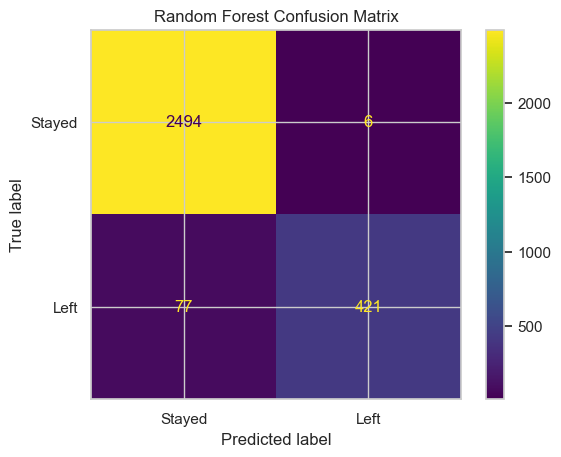

In [69]:
# Random forest confusion matrix

rf_cm = confusion_matrix(y_test, rf_pred)

rf_disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Stayed", "Left"]
)

rf_disp.plot(values_format="d")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [70]:
# Random forest performance summary

rf_results = pd.DataFrame({
    "model": ["Random Forest"],
    "accuracy": [accuracy_score(y_test, rf_pred)],
    "precision": [precision_score(y_test, rf_pred)],
    "recall": [recall_score(y_test, rf_pred)],
    "f1_score": [f1_score(y_test, rf_pred)],
    "roc_auc": [roc_auc_score(y_test, rf_pred)]
})

rf_results

,model,accuracy,precision,recall,f1_score,roc_auc
0,Random Forest,0.972315,0.985948,0.845382,0.91027,0.921491


In [71]:
# Random forest feature importance

rf_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="importance",
    ascending=False
)

rf_importance.head(10)

,feature,importance
0,satisfaction_level,0.357231
2,number_project,0.219797
4,tenure,0.157360
3,average_monthly_hours,0.139873
1,last_evaluation,0.106518
5,work_accident,0.009438
7,salary,0.006164
6,promotion_last_5years,0.000789
12,department_management,0.000624
9,department_RandD,0.000460


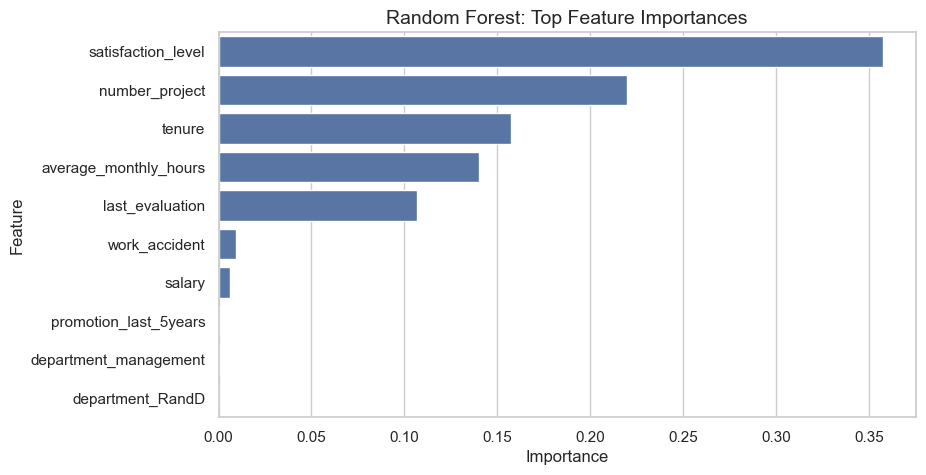

In [72]:
# Visualize top random forest feature importances

top_rf_importance = rf_importance.head(10)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=top_rf_importance,
    x="importance",
    y="feature"
)

plt.title("Random Forest: Top Feature Importances", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

The random forest model provides a stronger predictive benchmark than the baseline logistic regression model. Its feature importance results can help identify which workforce conditions are most closely associated with employee attrition in the dataset.

## 20. Model Comparison

This section compares the classification performance of the baseline logistic regression model, decision tree model, and random forest model.

The comparison helps identify which model provides the best balance of accuracy, precision, recall, F1-score, and ROC-AUC for employee attrition prediction.

In [73]:
model_comparison = pd.concat(
    [log_results, tree_results, rf_results],
    ignore_index=True
)

model_comparison

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.834556,0.505618,0.180723,0.266272,0.572761
1,Decision Tree,0.982989,0.972516,0.923695,0.947477,0.959247
2,Random Forest,0.972315,0.985948,0.845382,0.910270,0.921491


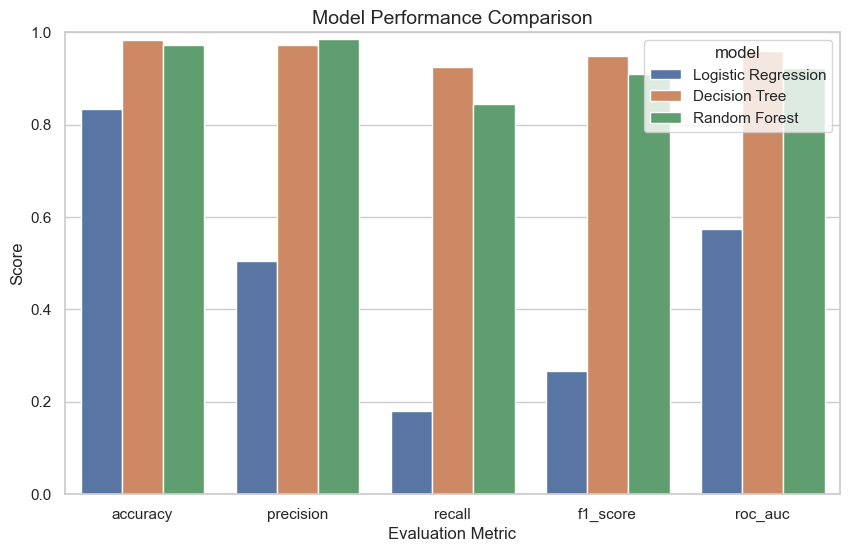

In [74]:
# Visualize model comparison by F1-score and recall

model_comparison_melted = model_comparison.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1_score", "roc_auc"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_comparison_melted,
    x="metric",
    y="score",
    hue="model"
)

plt.title("Model Performance Comparison", fontsize=14)
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.show()

The model comparison provides evidence for selecting a final model. For an HR retention use case, recall and F1-score are especially important because the organization may want to identify employees at risk of leaving while limiting unnecessary false alarms.

The final model should not be selected based only on accuracy. Accuracy can be misleading when the majority of employees stayed. A useful HR decision-support model should balance predictive performance, interpretability, and ethical usability.

## 21. Data Leakage and Real-World Deployment Considerations

Before finalizing a model, it is important to consider whether all input variables would be appropriate and available in a real-world HR decision-support setting.

Two variables require special attention:

1. `satisfaction_level`  
   Employee satisfaction is highly predictive, but it may not always be available, frequently updated, or consistently measured across all employees.

2. `average_monthly_hours`  
   Monthly working hours may partly reflect employee disengagement, resignation preparation, or managerial decisions after attrition risk has already emerged.

Using these variables may improve predictive performance, but it may also create concerns about data leakage or limited real-world deployability.

To make the portfolio version more realistic, this section creates an improved model design that:

- removes `satisfaction_level`
- transforms `average_monthly_hours` into a simpler business indicator called `overworked`
- focuses on features that are easier for HR stakeholders to interpret

## 22. Feature Engineering: Overworked Indicator

This section creates a new binary feature called `overworked`.

The feature is defined as:

```text
overworked = 1 if average_monthly_hours > 175
overworked = 0 otherwise

In [75]:
df_improved = df_model.copy()

# Create overworked feature
df_improved["overworked"] = (
    df_improved["average_monthly_hours"] > 175
).astype(int)

# Remove variables with potential deployment or leakage concerns
df_improved = df_improved.drop(
    columns=["satisfaction_level", "average_monthly_hours"]
)

print("Improved modeling dataset shape:", df_improved.shape)
df_improved.head()

Improved modeling dataset shape: (11991, 18)


,last_evaluation,number_project,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,overworked
0,0.53,2,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False,0
1,0.86,5,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False,1
2,0.88,7,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False,1
3,0.87,5,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False,1
4,0.52,2,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False,0


In [76]:
# Check overworked distribution

overworked_summary = df_improved["overworked"].value_counts(normalize=True).sort_index() * 100

pd.DataFrame({
    "overworked": overworked_summary.index,
    "percentage": overworked_summary.values
})

,overworked,percentage
0,0,36.368943
1,1,63.631057


In [77]:
# Attrition rate by overworked status

overworked_attrition = df_improved.groupby("overworked")["left"].agg(
    employee_count="count",
    attrition_rate="mean"
).reset_index()

overworked_attrition["attrition_rate_percent"] = (
    overworked_attrition["attrition_rate"] * 100
)

overworked_attrition

,overworked,employee_count,attrition_rate,attrition_rate_percent
0,0,4361,0.204082,20.408163
1,1,7630,0.144299,14.429882


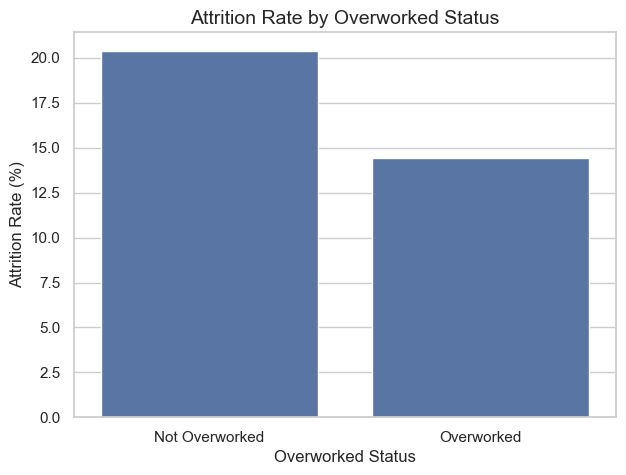

In [78]:
# Visualize attrition rate by overworked status

plt.figure(figsize=(7, 5))

sns.barplot(
    data=overworked_attrition,
    x="overworked",
    y="attrition_rate_percent"
)

plt.title("Attrition Rate by Overworked Status", fontsize=14)
plt.xlabel("Overworked Status")
plt.ylabel("Attrition Rate (%)")
plt.xticks(ticks=[0, 1], labels=["Not Overworked", "Overworked"])

plt.show()

## 23. Improved Model Dataset Split

This section rebuilds the training and testing datasets using the improved feature set.

Compared with the earlier model, this version removes `satisfaction_level` and replaces detailed monthly hours with the simpler `overworked` indicator.

This makes the model more conservative and more suitable for business interpretation.

In [79]:
X_improved = df_improved.drop("left", axis=1)
y_improved = df_improved["left"]

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved,
    y_improved,
    test_size=0.25,
    stratify=y_improved,
    random_state=42
)

print("X_train_imp shape:", X_train_imp.shape)
print("X_test_imp shape:", X_test_imp.shape)

print("\nTraining target distribution:")
print(y_train_imp.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test_imp.value_counts(normalize=True))

X_train_imp shape: (8993, 17)
X_test_imp shape: (2998, 17)

Training target distribution:
left
0    0.833982
1    0.166018
Name: proportion, dtype: float64

Testing target distribution:
left
0    0.833889
1    0.166111
Name: proportion, dtype: float64


## 24. Improved Random Forest Model

This section trains a random forest model using the improved feature set.

The purpose is not only to maximize predictive accuracy, but to create a model that is more realistic, interpretable, and suitable for HR decision-support discussion.

In [80]:
rf_improved = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=3,
    random_state=42
)

rf_improved.fit(X_train_imp, y_train_imp)

rf_imp_pred = rf_improved.predict(X_test_imp)

print("Improved Random Forest model trained successfully.")

Improved Random Forest model trained successfully.


In [81]:
# Classification report for improved random forest

print("Improved Random Forest Classification Report:")
print(classification_report(y_test_imp, rf_imp_pred))

Improved Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      2500
           1       0.94      0.66      0.78       498

    accuracy                           0.94      2998
   macro avg       0.94      0.83      0.87      2998
weighted avg       0.94      0.94      0.93      2998



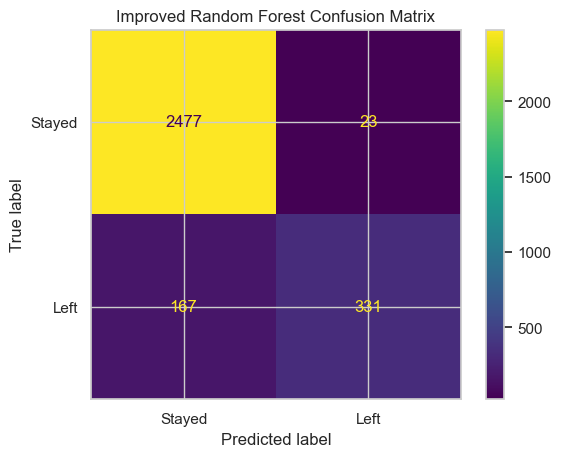

In [82]:
# Confusion matrix for improved random forest

rf_imp_cm = confusion_matrix(y_test_imp, rf_imp_pred)

rf_imp_disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_imp_cm,
    display_labels=["Stayed", "Left"]
)

rf_imp_disp.plot(values_format="d")
plt.title("Improved Random Forest Confusion Matrix")
plt.show()

In [83]:
# Improved random forest performance summary

rf_improved_results = pd.DataFrame({
    "model": ["Improved Random Forest"],
    "accuracy": [accuracy_score(y_test_imp, rf_imp_pred)],
    "precision": [precision_score(y_test_imp, rf_imp_pred)],
    "recall": [recall_score(y_test_imp, rf_imp_pred)],
    "f1_score": [f1_score(y_test_imp, rf_imp_pred)],
    "roc_auc": [roc_auc_score(y_test_imp, rf_imp_pred)]
})

rf_improved_results

,model,accuracy,precision,recall,f1_score,roc_auc
0,Improved Random Forest,0.936624,0.935028,0.664659,0.776995,0.827729


In [84]:
# Compare original and improved random forest models

rf_comparison = pd.concat(
    [rf_results, rf_improved_results],
    ignore_index=True
)

rf_comparison

,model,accuracy,precision,recall,f1_score,roc_auc
0,Random Forest,0.972315,0.985948,0.845382,0.910270,0.921491
1,Improved Random Forest,0.936624,0.935028,0.664659,0.776995,0.827729


The improved model may perform slightly differently from the earlier random forest model because it removes potentially sensitive or deployment-limited variables. This tradeoff is acceptable in a decision-support context if the model becomes more interpretable, more realistic, and less dependent on variables that may not be consistently available.

## 25. Improved Model Feature Importance

Feature importance is used to explain which variables contribute most to the improved model.

This supports stakeholder communication because HR decision-makers need to understand the main drivers behind the model instead of only seeing prediction scores.

In [86]:
rf_imp_importance = pd.DataFrame({
    "feature": X_improved.columns,
    "importance": rf_improved.feature_importances_
})

rf_imp_importance = rf_imp_importance.sort_values(
    by="importance",
    ascending=False
)

rf_imp_importance.head(10)

,feature,importance
1,number_project,0.399164
2,tenure,0.257854
0,last_evaluation,0.212205
16,overworked,0.087359
3,work_accident,0.020068
5,salary,0.015375
4,promotion_last_5years,0.001724
7,department_RandD,0.001059
10,department_management,0.000933
13,department_sales,0.000931


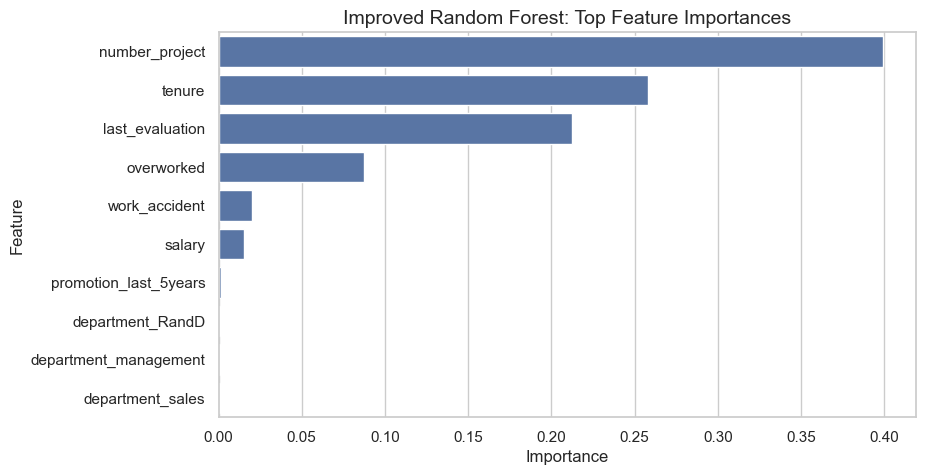

In [87]:
# Visualize improved random forest feature importance

top_rf_imp_importance = rf_imp_importance.head(10)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=top_rf_imp_importance,
    x="importance",
    y="feature"
)

plt.title("Improved Random Forest: Top Feature Importances", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 26. Workforce Risk Segmentation

A portfolio-enhanced version of this project should not stop at model prediction.

This section translates model probabilities into risk segments that HR stakeholders can interpret.

The model estimates the probability that an employee may leave. These probabilities are grouped into four risk levels:

| Risk Segment | Probability Range | Interpretation |
|---|---:|---|
| Low Risk | < 0.25 | Low predicted attrition risk |
| Moderate Risk | 0.25–0.50 | Some risk signals present |
| High Risk | 0.50–0.75 | Stronger attrition concern |
| Critical Risk | >= 0.75 | Highest priority for HR review |

This segmentation is designed for decision support, not automatic employee labeling.

In [88]:
# Predict probability of attrition
risk_probabilities = rf_improved.predict_proba(X_test_imp)[:, 1]

risk_results = X_test_imp.copy()
risk_results["actual_left"] = y_test_imp.values
risk_results["predicted_left"] = rf_imp_pred
risk_results["attrition_risk_probability"] = risk_probabilities

def assign_risk_segment(probability):
    if probability >= 0.75:
        return "Critical Risk"
    elif probability >= 0.50:
        return "High Risk"
    elif probability >= 0.25:
        return "Moderate Risk"
    else:
        return "Low Risk"

risk_results["risk_segment"] = risk_results["attrition_risk_probability"].apply(assign_risk_segment)

risk_results.head()

,last_evaluation,number_project,tenure,work_accident,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,overworked,actual_left,predicted_left,attrition_risk_probability,risk_segment
11098,0.83,4,3,0,0,1,False,False,False,False,True,False,False,False,False,False,1,0,0,0.051932,Low Risk
5472,0.64,5,4,1,0,1,False,False,False,False,False,False,False,False,True,False,1,0,0,0.105850,Low Risk
7367,0.78,2,2,0,0,1,False,False,False,False,False,False,False,False,False,True,1,0,0,0.056734,Low Risk
3605,0.81,4,2,0,0,0,False,False,False,False,False,False,False,True,False,False,1,0,0,0.035962,Low Risk
3248,0.62,3,2,1,0,1,False,False,False,False,False,False,False,False,False,True,0,0,0,0.005461,Low Risk


In [89]:
# Risk segment summary

risk_segment_summary = risk_results["risk_segment"].value_counts().reset_index()
risk_segment_summary.columns = ["risk_segment", "employee_count"]

risk_segment_summary["percentage"] = (
    risk_segment_summary["employee_count"] / len(risk_results) * 100
)

risk_segment_summary

,risk_segment,employee_count,percentage
0,Low Risk,2363,78.819213
1,Moderate Risk,281,9.372915
2,Critical Risk,198,6.604403
3,High Risk,156,5.203469


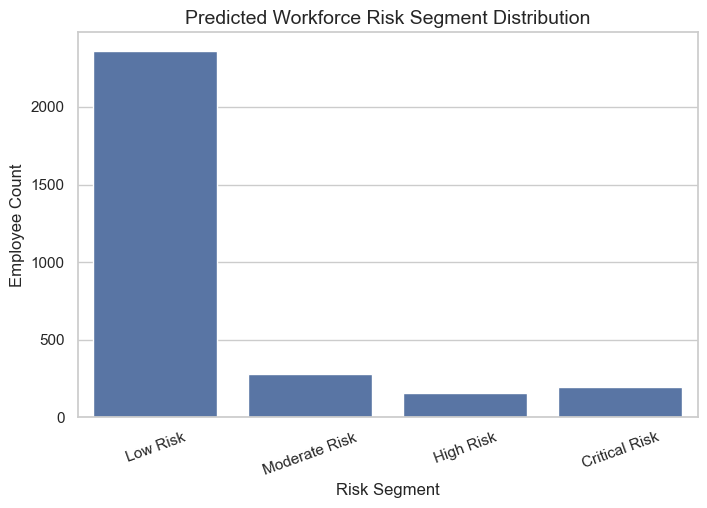

In [90]:
# Visualize risk segment distribution

risk_order = ["Low Risk", "Moderate Risk", "High Risk", "Critical Risk"]

plt.figure(figsize=(8, 5))

sns.countplot(
    data=risk_results,
    x="risk_segment",
    order=risk_order
)

plt.title("Predicted Workforce Risk Segment Distribution", fontsize=14)
plt.xlabel("Risk Segment")
plt.ylabel("Employee Count")
plt.xticks(rotation=20)

plt.show()

In [91]:
# Actual attrition rate by predicted risk segment

risk_segment_performance = risk_results.groupby("risk_segment")["actual_left"].agg(
    employee_count="count",
    actual_attrition_rate="mean"
).reset_index()

risk_segment_performance["actual_attrition_rate_percent"] = (
    risk_segment_performance["actual_attrition_rate"] * 100
)

risk_segment_performance["risk_segment"] = pd.Categorical(
    risk_segment_performance["risk_segment"],
    categories=risk_order,
    ordered=True
)

risk_segment_performance = risk_segment_performance.sort_values("risk_segment")

risk_segment_performance

,risk_segment,employee_count,actual_attrition_rate,actual_attrition_rate_percent
2,Low Risk,2363,0.015235,1.523487
3,Moderate Risk,281,0.466192,46.619217
1,High Risk,156,0.897436,89.743590
0,Critical Risk,198,0.964646,96.464646


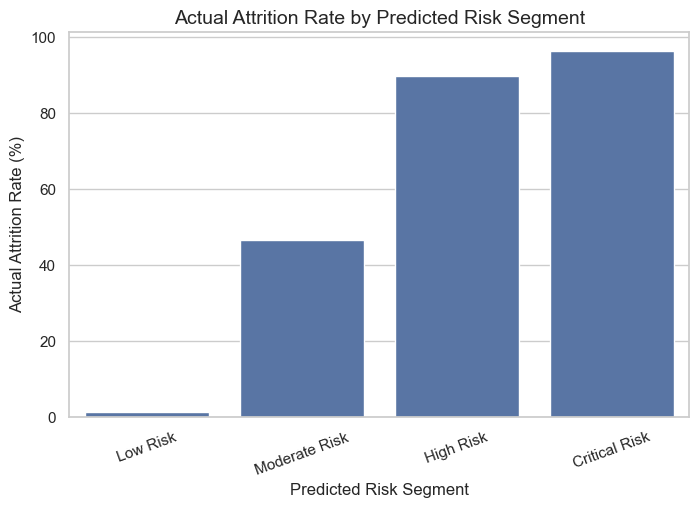

In [92]:
# Visualize actual attrition rate by predicted risk segment

plt.figure(figsize=(8, 5))

sns.barplot(
    data=risk_segment_performance,
    x="risk_segment",
    y="actual_attrition_rate_percent",
    order=risk_order
)

plt.title("Actual Attrition Rate by Predicted Risk Segment", fontsize=14)
plt.xlabel("Predicted Risk Segment")
plt.ylabel("Actual Attrition Rate (%)")
plt.xticks(rotation=20)

plt.show()

Risk segmentation helps translate model output into an HR decision-support format. Instead of presenting only binary predictions, the model can help HR prioritize attention across different levels of workforce risk.

However, these risk segments should be used carefully. They should support further investigation, manager conversations, workload review, and retention planning rather than punitive action against individual employees.

## 27. HR Action Matrix

The final step is to translate analytical results into practical HR actions.

The following action matrix connects risk segments with recommended HR responses.

In [93]:
hr_action_matrix = pd.DataFrame({
    "Risk Segment": [
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Critical Risk"
    ],
    "Suggested HR Response": [
        "Maintain current engagement strategy and continue monitoring general workforce indicators.",
        "Review workload, project assignment, and employee feedback patterns.",
        "Conduct manager-level review and consider targeted retention support.",
        "Prioritize immediate HR review, workload adjustment, promotion discussion, or retention intervention."
    ],
    "Example Action": [
        "Routine engagement survey and standard performance support.",
        "Check whether workload or project count is increasing.",
        "Schedule confidential check-in or review career development needs.",
        "Develop individualized retention plan or team-level workload redistribution."
    ],
    "Ethical Caution": [
        "Avoid ignoring low-risk employees completely.",
        "Do not assume the employee will leave; investigate context.",
        "Use the model as a signal, not as proof.",
        "Do not punish or stigmatize employees based on predicted risk."
    ]
})

hr_action_matrix

,Risk Segment,Suggested HR Response,Example Action,Ethical Caution
0,Low Risk,Maintain current engagement strategy and conti...,Routine engagement survey and standard perform...,Avoid ignoring low-risk employees completely.
1,Moderate Risk,"Review workload, project assignment, and emplo...",Check whether workload or project count is inc...,Do not assume the employee will leave; investi...
2,High Risk,Conduct manager-level review and consider targ...,Schedule confidential check-in or review caree...,"Use the model as a signal, not as proof."
3,Critical Risk,"Prioritize immediate HR review, workload adjus...",Develop individualized retention plan or team-...,Do not punish or stigmatize employees based on...


The HR action matrix demonstrates how predictive analytics can be translated into decision support. The recommendations are intentionally framed as supportive interventions rather than enforcement actions.

## 28. Final Business Recommendations

Based on the exploratory analysis, model results, feature importance, and risk segmentation framework, the following recommendations can be presented to HR stakeholders:

1. **Monitor workload pressure.**  
   Employees with high monthly working hours or overworked status may require workload review.

2. **Review project allocation.**  
   Employees assigned to many projects may experience role overload. Project assignment should be monitored as a retention-related workforce indicator.

3. **Investigate promotion and career development pathways.**  
   Lack of promotion may contribute to dissatisfaction or turnover risk. HR should review whether employees have clear advancement opportunities.

4. **Use risk segmentation for support, not punishment.**  
   Predicted risk should trigger further investigation and support, not negative treatment.

5. **Develop a retention dashboard.**  
   A Tableau dashboard can help HR track attrition rate, overwork rate, project overload rate, promotion gap rate, and high-risk employee share.

6. **Validate the model before deployment.**  
   Additional data, stakeholder review, fairness analysis, and real-world validation would be necessary before using this model operationally.

## 29. Portfolio Summary

This notebook extends a standard employee attrition prediction task into a workforce retention risk decision-support project.

The project demonstrates the following skills:

- Data cleaning and preparation
- Exploratory data analysis
- Classification modeling
- Model evaluation
- Feature importance interpretation
- Data leakage awareness
- KPI-oriented business interpretation
- Risk segmentation
- Ethical analytics framing
- HR stakeholder communication

The main value of this portfolio project is not only the predictive model itself, but the translation of model outputs into practical, responsible, and stakeholder-facing workforce recommendations.

This supports a broader analytics positioning focused on connecting technical modeling with business decision-making.